In [16]:
import cv2
import torch
import random
from torch import nn
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

# flip and rotate mri images to gte more data for training
def get_train_augmentation(size=256):
    return A.Compose([
        A.Resize(size, size),  
        A.HorizontalFlip(p=0.5), 

        A.Rotate(limit=20, p=0.8, border_mode=cv2.BORDER_CONSTANT), 

        A.RandomBrightnessContrast(p=0.2),

        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), 

        ToTensorV2(),
    ])

In [17]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# get all image and mask paths
data_dir = Path("lgg-mri-segmentation/kaggle_3m")

all_files = list(data_dir.glob("*/*.tif"))

# create a dataframe that include all images and masks
df = pd.DataFrame({"path": [str(p) for p in all_files]})

# split images and masks
mask_df = df[df["path"].str.contains("mask")].copy()
image_df = df[~df["path"].str.contains("mask")].copy()

mask_df["match_id"] = mask_df["path"].str.replace("_mask.tif", ".tif")

# based on the id match them together
final_df = pd.merge(image_df, mask_df, left_on="path", right_on="match_id", how="inner")
final_df = final_df.rename(columns={"path_x": "image_path", "path_y": "mask_path"})
final_df = final_df[["image_path", "mask_path"]]
print(final_df.head())

# prepare dataset class
class BrainMriDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") 
        
        if self.transform:
            image_np = np.array(image)
            mask_np = np.array(mask)

            augmented = self.transform(image=image_np, mask=mask_np)

      
            image = augmented['image']
            mask = augmented['mask']
            mask = mask.float() / 255.0
            
        return image, mask


train_transform = get_train_augmentation(size=256)
train_df, val_df = train_test_split(final_df, test_size=0.1, random_state=42)


train_dataset = BrainMriDataset(train_df, transform=train_transform) 

val_transform = A.Compose([A.Resize(256, 256), A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), ToTensorV2()])
val_dataset = BrainMriDataset(val_df, transform=val_transform)

                                          image_path  \
0  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...   
1  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...   
2  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...   
3  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...   
4  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...   

                                           mask_path  
0  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...  
1  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...  
2  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...  
3  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...  
4  lgg-mri-segmentation\kaggle_3m\TCGA_CS_4941_19...  


In [18]:
# implement double conv block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [19]:
# implement down block
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels) 
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [20]:
# implement up block
class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        
        x1 = self.up(x1) 

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        import torch.nn.functional as F
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
 
        x = torch.cat([x2, x1], dim=1)
        
        return self.conv(x)

In [21]:
# implement out block
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [22]:
# The acutal unet model
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inc = DoubleConv(n_channels, 64)
        
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024) 

        self.up1 = Up(1024, 512) 
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) 
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

In [23]:
# combine BCE and Dice loss together
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + self.smooth)/(inputs.sum() + targets.sum() + self.smooth)
        
        return 1 - dice

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

In [24]:
import torch.optim as optim

# use gpu to run the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

# define unet model
model = UNet(n_channels=3, n_classes=1).to(device)

# use adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4) 

num_epochs = 10  

history = {
    'train_loss': [], 'train_dice': [],
    'val_loss': [], 'val_dice': []
}

BATCH_SIZE = 16 
NUM_WORKERS = 0 

# prepare dataloaders for training and validation
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS
)

print(f"Batch Size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# calculate dice coefficient
def dice_coeff(pred, target):
    smooth = 1.
    pred = torch.sigmoid(pred).view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# training loop
for epoch in range(num_epochs):
    torch.cuda.empty_cache() 
    
    model.train() 
    running_loss = 0.0
    running_dice = 0.0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)")
    
    for images, masks in train_loop: 
        images = images.to(device)
        
        masks = masks.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_coeff(outputs, masks).item()
        
        train_loop.set_postfix({'Loss': loss.item(), 'Dice': running_dice / (train_loop.n + 1)})

    epoch_loss = running_loss / len(train_loader)
    epoch_dice = running_dice / len(train_loader)
    
    history['train_loss'].append(epoch_loss)
    history['train_dice'].append(epoch_dice)
    

    model.eval()
    val_running_loss = 0.0
    val_running_dice = 0.0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            
            masks = masks.to(device).float().unsqueeze(1)

            outputs = model(images)
            
            loss = combined_loss(outputs, masks)
            
            val_running_loss += loss.item()
            val_running_dice += dice_coeff(outputs, masks).item()
            
    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_dice = val_running_dice / len(val_loader)
    
    history['val_loss'].append(val_epoch_loss)
    history['val_dice'].append(val_epoch_dice)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Summary:")
    print(f"Train loss: {epoch_loss:.4f}, Dice coefficient: {epoch_dice:.4f}")
    print(f"Val loss: {val_epoch_loss:.4f}, Dice coefficient: {val_epoch_dice:.4f}")

Batch Size: 16
Train batches: 221
Val batches: 25


Epoch 1/10 (Train): 100%|██████████| 221/221 [02:27<00:00,  1.50it/s, Loss=0.539, Dice=0.051] 


Epoch [1/10] Summary:
Train loss: 0.6378 | Dice coefficient: 0.0510
Val loss: 0.6010 | Dice coefficient: 0.0609


Epoch 2/10 (Train): 100%|██████████| 221/221 [02:24<00:00,  1.53it/s, Loss=0.526, Dice=0.0816]


Epoch [2/10] Summary:
Train loss: 0.5595 | Dice coefficient: 0.0816
Val loss: 0.5431 | Dice coefficient: 0.0836


...

Epoch [8/10] Summary:
Train loss: 0.2119 | Dice coefficient: 0.6006
Val loss: 0.2016 | Dice coefficient: 0.6166


Epoch 9/10 (Train): 100%|██████████| 221/221 [02:22<00:00,  1.55it/s, Loss=0.264, Dice=0.669] 


Epoch [9/10] Summary:
Train loss: 0.1762 | Dice coefficient: 0.6689
Val loss: 0.1685 | Dice coefficient: 0.6798


Epoch 10/10 (Train): 100%|██████████| 221/221 [02:21<00:00,  1.56it/s, Loss=0.115, Dice=0.692] 


Epoch [10/10] Summary:
Train loss: 0.1648 | Dice coefficient: 0.6922
Val loss: 0.1413 | Dice coefficient: 0.7335


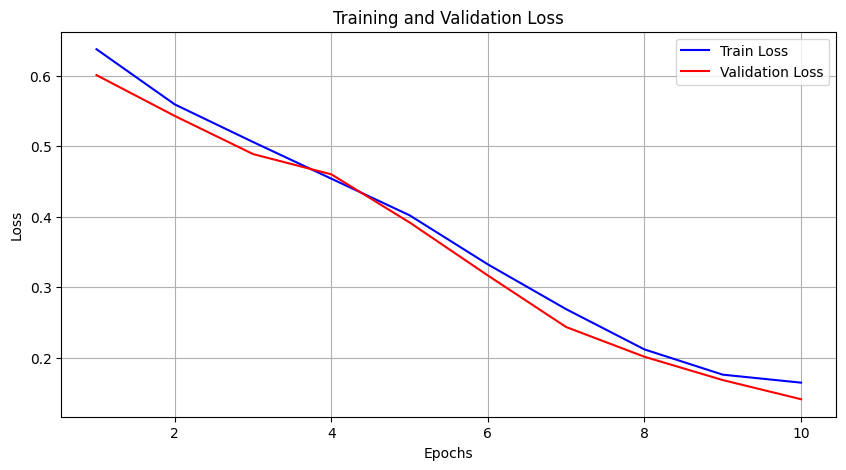

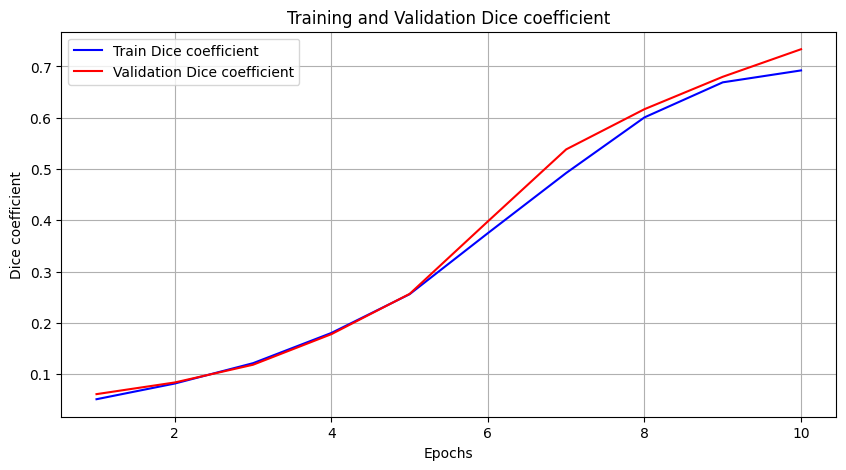

In [25]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['train_loss'], 'b', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r', label='Validation Loss')
    
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['train_dice'], 'b', label='Train Dice coefficient')
    plt.plot(epochs, history['val_dice'], 'r', label='Validation Dice coefficient')
    
    plt.title('Training and Validation Dice coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice coefficient')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

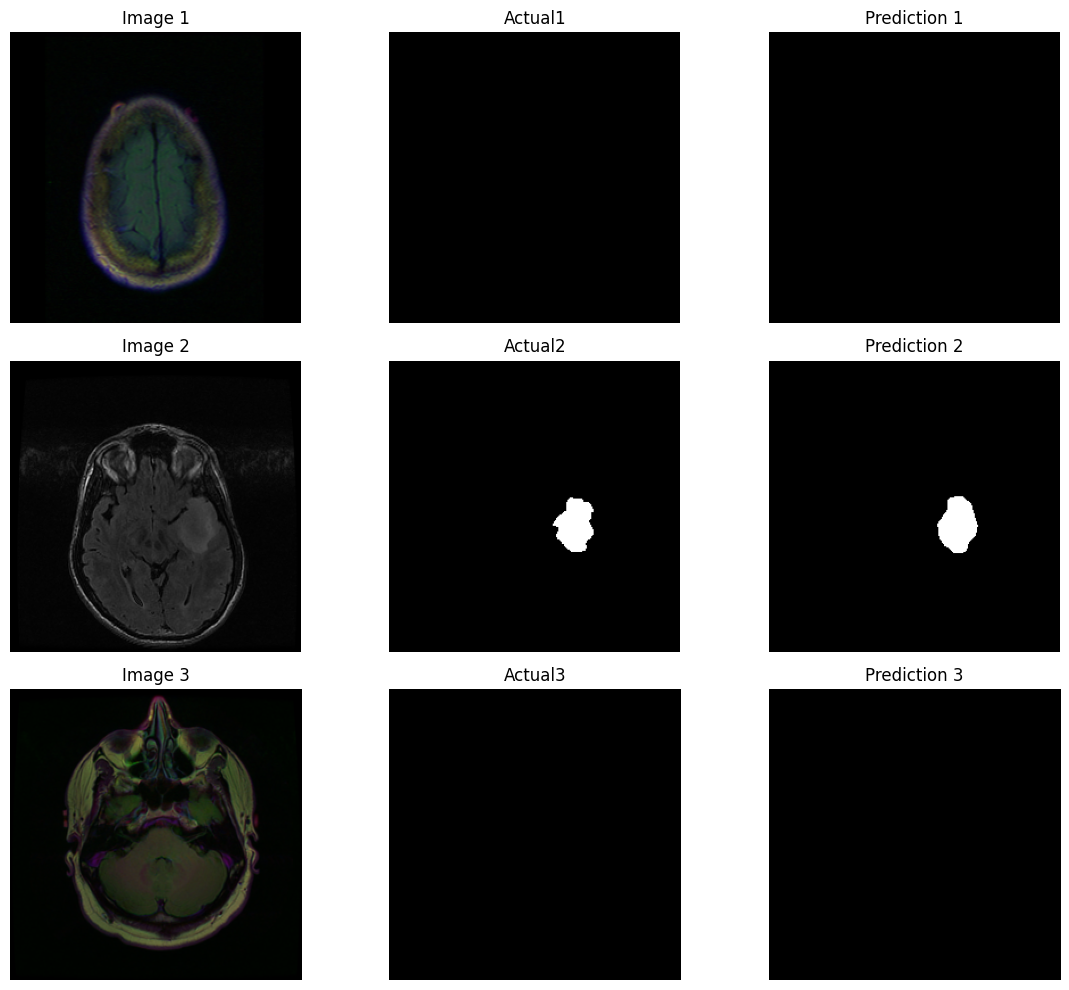

In [26]:
import matplotlib.pyplot as plt
import random

check_loader = DataLoader(val_dataset, batch_size=4, shuffle=True)

images, masks = next(iter(check_loader))
images = images.to(device)
masks = masks.to(device).float().unsqueeze(1)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.sigmoid(outputs) > 0.5 

plt.figure(figsize=(12, 10))

for idx in range(3): 
    img_display = images[idx].cpu().permute(1, 2, 0)
    
    img_display = img_display * 0.5 + 0.5
    
    img_display = torch.clamp(img_display, 0, 1)

    plt.subplot(3, 3, idx*3 + 1)
    plt.imshow(img_display) 
    plt.title(f"Image {idx+1}")
    plt.axis("off")
    
    plt.subplot(3, 3, idx*3 + 2)
    plt.imshow(masks[idx].cpu().squeeze(), cmap='gray')
    plt.title(f"Actual{idx+1}")
    plt.axis("off")

    plt.subplot(3, 3, idx*3 + 3)
    plt.imshow(preds[idx].cpu().squeeze(), cmap='gray')
    plt.title(f"Prediction {idx+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()